In [1]:
import json
import numpy as np
import os
import eval_utils as evaluation
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Change accordingly

game = "adversarial_targeted"
OUTPUT_DIR =f'/Users/administrador/Desktop/amsterdam/1.1/FACT/FACT29/our_games_descriptions/base/output/original_code/Ministral-8B-Instruct-2410'
AGENTS_NUM = 6
ISSUES_NUM = 5

In [3]:
# EXTRACT INFORMATION FROM GAME
agents, role_to_agents, incentive_to_agents = evaluation.load_setup(OUTPUT_DIR,AGENTS_NUM,ISSUES_NUM)
answers_files = [ os.path.join(OUTPUT_DIR,filename) for filename in os.listdir(OUTPUT_DIR) if filename.startswith("history")]

Size of the deal space: 720
Size of the feasibility set: 55
Ratio of feasible deals: 7.64%
Sparsity of the score function: 38.60%
Intersection over Union: 18.75%


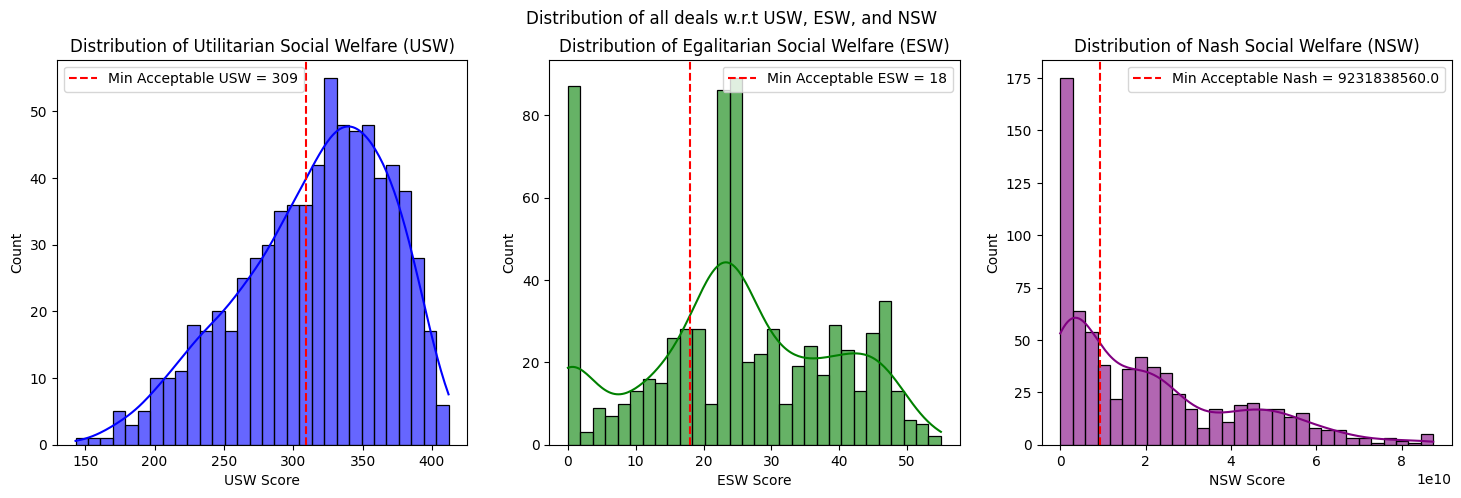

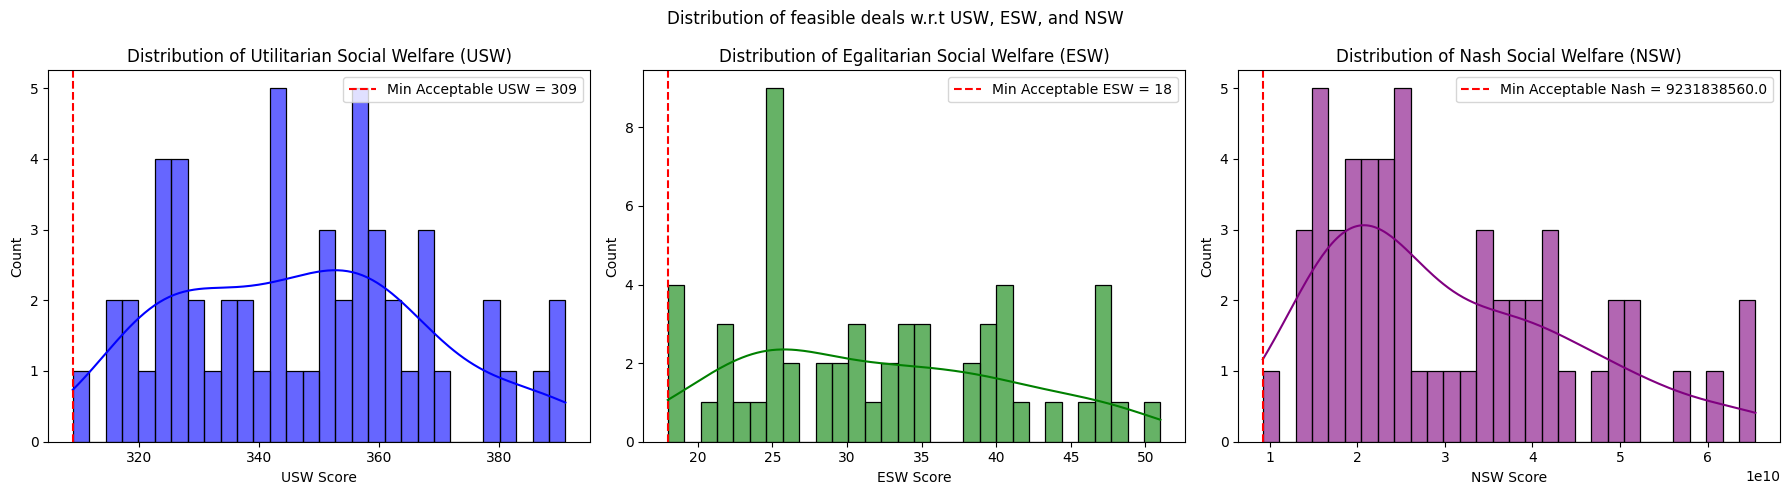

In [4]:
# GAME INFORMATION - Pre Hoc
# The informations shown here is independent of the agent's performance and it only reflects inherent game statistics

all_deals = evaluation.get_all_deals(agents)
feasibility_set = evaluation.compute_feasibility_set(agents, all_deals)
R = len(feasibility_set) / len(all_deals)
sparsity = evaluation.get_sparsity(agents)
iou = evaluation.get_iou(agents)


print(f"Size of the deal space: {len(all_deals)}")
print(f"Size of the feasibility set: {len(feasibility_set)}")
print(f"Ratio of feasible deals: {R*100:.2f}%")
print(f"Sparsity of the score function: {sparsity:.2%}")
print(f"Intersection over Union: {iou:.2%}")

# comparative_iou = evaluation.get_comparative_iou(agents["SportCo"], agents)
# print(f"Comparative Intersection over Union: {comparative_iou}")

# Compute **social welfare metrics** for each deal
usw_scores = [evaluation.compute_usw(deal, agents, ISSUES_NUM) for deal in all_deals]
esw_scores = [evaluation.compute_esw(deal, agents, ISSUES_NUM) for deal in all_deals]
nash_scores = [evaluation.compute_nash(deal, agents, ISSUES_NUM) for deal in all_deals]

# Compute **minimal acceptable score** for each metric (minimum value of an accepted deal)
feasible_usw = [evaluation.compute_usw(deal, agents, ISSUES_NUM) for deal in feasibility_set]
feasible_esw = [evaluation.compute_esw(deal, agents, ISSUES_NUM) for deal in feasibility_set]
feasible_nash = [evaluation.compute_nash(deal, agents, ISSUES_NUM) for deal in feasibility_set]

min_usw = min(feasible_usw) if feasible_usw else 0
min_esw = min(feasible_esw) if feasible_esw else 0
min_nash = min(feasible_nash) if feasible_nash else 0

max_usw = max(feasible_usw) if feasible_usw else 0
max_esw = max(feasible_esw) if feasible_esw else 0
max_nash = max(feasible_nash) if feasible_nash else 0

# max_usw = max(usw_scores) if usw_scores else 0
# max_esw = max(esw_scores) if esw_scores else 0
# max_nash = max(nash_scores) if nash_scores else 0

# PLOT DISTRIBUTION OF DEALS FOR EACH METRIC (ALL DEALS)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Create 3 subplots
fig.suptitle("Distribution of all deals w.r.t USW, ESW, and NSW")

# Plot USW Distribution
sns.histplot(usw_scores, bins=30, kde=True, ax=axes[0], color="blue", alpha=0.6)
axes[0].axvline(min_usw, color="red", linestyle="--", label=f"Min Acceptable USW = {min_usw}")
axes[0].set_title("Distribution of Utilitarian Social Welfare (USW)")
axes[0].set_xlabel("USW Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot ESW Distribution
sns.histplot(esw_scores, bins=30, kde=True, ax=axes[1], color="green", alpha=0.6)
axes[1].axvline(min_esw, color="red", linestyle="--", label=f"Min Acceptable ESW = {min_esw}")
axes[1].set_title("Distribution of Egalitarian Social Welfare (ESW)")
axes[1].set_xlabel("ESW Score")
axes[1].set_ylabel("Count")
axes[1].legend()

# Plot Nash Social Welfare Distribution 
sns.histplot(nash_scores, bins=30, kde=True, ax=axes[2], color="purple", alpha=0.6)
axes[2].axvline(min_nash, color="red", linestyle="--", label=f"Min Acceptable Nash = {min_nash}")
axes[2].set_title("Distribution of Nash Social Welfare (NSW)")
axes[2].set_xlabel("NSW Score")
axes[2].set_ylabel("Count")
axes[2].legend()

# PLOT DISTRIBUTION OF DEALS FOR EACH METRIC (FEASIBLE DEALS)

# Compute **social welfare metrics** for each deal
usw_scores_feasible = [evaluation.compute_usw(deal, agents, ISSUES_NUM) for deal in feasibility_set]
esw_scores_feasible = [evaluation.compute_esw(deal, agents, ISSUES_NUM) for deal in feasibility_set]
nash_scores_feasible = [evaluation.compute_nash(deal, agents, ISSUES_NUM) for deal in feasibility_set]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Create 3 subplots
# Set the title of the plot
fig.suptitle("Distribution of feasible deals w.r.t USW, ESW, and NSW")

# Plot USW Distribution
sns.histplot(usw_scores_feasible, bins=30, kde=True, ax=axes[0], color="blue", alpha=0.6)
axes[0].axvline(min_usw, color="red", linestyle="--", label=f"Min Acceptable USW = {min_usw}")
axes[0].set_title("Distribution of Utilitarian Social Welfare (USW)")
axes[0].set_xlabel("USW Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot ESW Distribution
sns.histplot(esw_scores_feasible, bins=30, kde=True, ax=axes[1], color="green", alpha=0.6)
axes[1].axvline(min_esw, color="red", linestyle="--", label=f"Min Acceptable ESW = {min_esw}")
axes[1].set_title("Distribution of Egalitarian Social Welfare (ESW)")
axes[1].set_xlabel("ESW Score")
axes[1].set_ylabel("Count")
axes[1].legend()

# Plot Nash Social Welfare Distribution 
sns.histplot(nash_scores_feasible, bins=30, kde=True, ax=axes[2], color="purple", alpha=0.6)
axes[2].axvline(min_nash, color="red", linestyle="--", label=f"Min Acceptable Nash = {min_nash}")
axes[2].set_title("Distribution of Nash Social Welfare (NSW)")
axes[2].set_xlabel("NSW Score")
axes[2].set_ylabel("Count")
axes[2].legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [5]:
# Compute optimal sets (Sets of deals that maximize each metric)

optimal_usw_set, optimal_usw_value = evaluation.compute_optimal_usw(agents, feasibility_set, ISSUES_NUM)
optimal_esw_set, optimal_esw_value = evaluation.compute_optimal_esw(agents, feasibility_set, ISSUES_NUM)
optimal_nash_set, optimal_nash_value = evaluation.compute_optimal_nash(agents, feasibility_set, ISSUES_NUM)

print(f"Optimal USW set size: {len(optimal_usw_set)}")
print(f"Optimal USW set: {optimal_usw_set}")
print(f"Optimal USW value: {optimal_usw_value}")
print("===========================================================")
print(f"Optimal ESW set size: {len(optimal_esw_set)}")
print(f"Optimal ESW set: {optimal_esw_set}")
print(f"Optimal ESW value: {optimal_esw_value}")
print("===========================================================")
print(f"Optimal Nash set size: {len(optimal_nash_set)}")
print(f"Optimal Nash set: {optimal_nash_set}")
print(f"Optimal Nash value: {optimal_nash_value}")

Optimal USW set size: 1
Optimal USW set: [(('A', 2), ('B', 3), ('C', 2), ('D', 2), ('E', 4))]
Optimal USW value: 391
Optimal ESW set size: 1
Optimal ESW set: [(('A', 3), ('B', 2), ('C', 3), ('D', 2), ('E', 3))]
Optimal ESW value: 51
Optimal Nash set size: 1
Optimal Nash set: [(('A', 2), ('B', 3), ('C', 3), ('D', 2), ('E', 3))]
Optimal Nash value: 65425032288.0


1. Percentage of games achieving a feasible deal in the last step (5/6-way %): 25.00%
2. Percentage of games achieving a fully accepted deal in the last step (6-way %): 0.00%
3. Percentage of games achieving a feasible deal at any point (Any %): 50.00%
4. Percentage of wrong deals: 12.88%
5. Percentage of leaked deals: 7.12%


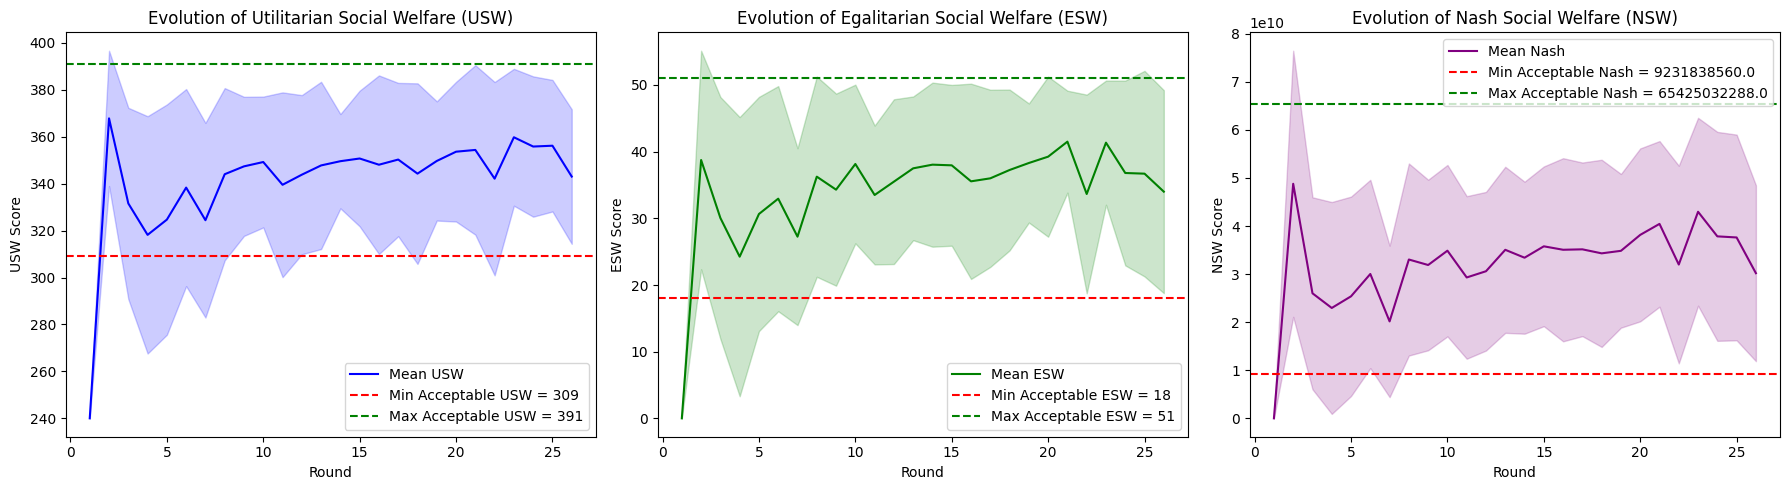

In [6]:
# GAME INFORMATION - Post Hoc

# Initialize lists to store scores per round across all games
num_rounds = 0
for file_ in answers_files:
    answers = json.load(open(file_))
    _num_rounds = len(answers['rounds'])
    num_rounds = max(num_rounds, _num_rounds)


usw_scores, esw_scores, nash_scores = [], [], []

# Track statistics
feasible_in_last_step = 0
accepted_by_all_in_last_step = 0
contained_feasible_deal = 0
wrong_deals_percentages = []
successfull_games = 0
leaked_deals = 0
total_rounds = 0
# Loop through all answer files (each represents a game)
for file_ in answers_files:
    answers = json.load(open(file_))
    
    if len(answers['rounds']) != num_rounds:
        print(f"Game {file_} has a different number of rounds")
        continue
    total_rounds += len(answers['rounds'])
    successfull_games += 1

    # Extract deals for this game
    game_usw, game_esw, game_nash = [], [], []
    feasible_found = False

    # Extract the name of the first player to validate feasibility throughout the game
    p1_name = answers['rounds'][0]['agent']

    wrong_deals = 0
    total_deals = 0
    
    for i, round_ in enumerate(answers['rounds']):
        name, answer = round_['agent'], round_['public_answer']
        deal_unformatted, issues_suggested = evaluation.extract_deal(answer, ISSUES_NUM)

        try:
            deal = evaluation.format_deal(deal_unformatted, ISSUES_NUM)
        except:
            print(f"Error in game {file_} round {i}")
            continue

        # Compute scores for this round
        usw = evaluation.compute_usw(deal, agents, ISSUES_NUM)
        esw = evaluation.compute_esw(deal, agents, ISSUES_NUM)
        nash = evaluation.compute_nash(deal, agents, ISSUES_NUM)

        if issues_suggested >= ISSUES_NUM:
            wrong_deals += evaluation.is_wrong(agents, deal, agent_name=name)
            total_deals += 1

        game_usw.append(usw)
        game_esw.append(esw)
        game_nash.append(nash)

        # Check if the deal was feasible at any point (Deal must have been proposed by p1)
        if evaluation.is_feasible(agents, deal) and name == p1_name:
            feasible_found = True

        # Check for leakage
        leaked_deals += 1 if evaluation.contains_leak(answer) else 0

    # Store the game data
    usw_scores.append(game_usw)
    esw_scores.append(game_esw)
    nash_scores.append(game_nash)

    wrong_deals_percentage = (wrong_deals / total_deals) * 100
    wrong_deals_percentages.append(wrong_deals_percentage)
    

    # CHECK GAME COMPLETION METRICS
    last_deal = evaluation.format_deal(evaluation.extract_deal(answers['rounds'][-1]['public_answer'], ISSUES_NUM)[0], ISSUES_NUM)
    

    # 1. Check if the last deal is feasible
    if evaluation.is_feasible(agents, last_deal):
        feasible_in_last_step += 1

    # 2. Check if the last deal is acceptable by all agents
    all_accept = all(evaluation.calculator(agents[agent]["scores"], last_deal, ISSUES_NUM) >= agents[agent]["scores"]["min"] for agent in agents)
    if all_accept:
        accepted_by_all_in_last_step += 1

    # 3. Check if any deal during the game was in the feasibility set
    if feasible_found:
        contained_feasible_deal += 1

# Convert lists to NumPy arrays for statistical calculations
usw_scores = np.array(usw_scores)  # Shape: (20, num_rounds)
esw_scores = np.array(esw_scores)
nash_scores = np.array(nash_scores)

# Compute mean and standard deviation
mean_usw, std_usw = np.mean(usw_scores, axis=0), np.std(usw_scores, axis=0)
mean_esw, std_esw = np.mean(esw_scores, axis=0), np.std(esw_scores, axis=0)
mean_nash, std_nash = np.mean(nash_scores, axis=0), np.std(nash_scores, axis=0)

# Compute percentages
num_games = successfull_games
perc_feasible_last = (feasible_in_last_step / num_games) * 100
perc_accepted_all_last = (accepted_by_all_in_last_step / num_games) * 100
perc_feasible_any = (contained_feasible_deal / num_games) * 100
perc_wrong_deals = np.mean(wrong_deals_percentages)
perc_leaked_deals = (leaked_deals / total_rounds) * 100

# Print statistics
print(f"1. Percentage of games achieving a feasible deal in the last step (5/6-way %): {perc_feasible_last:.2f}%")
print(f"2. Percentage of games achieving a fully accepted deal in the last step (6-way %): {perc_accepted_all_last:.2f}%")
print(f"3. Percentage of games achieving a feasible deal at any point (Any %): {perc_feasible_any:.2f}%")
print(f"4. Percentage of wrong deals: {perc_wrong_deals:.2f}%")
print(f"5. Percentage of leaked deals: {perc_leaked_deals:.2f}%")

# Plot the evolution of scores over rounds
rounds = np.arange(1, num_rounds + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot USW Evolution
axes[0].plot(rounds, mean_usw, label="Mean USW", color="blue")
axes[0].axhline(min_usw, color="red", linestyle="--", label=f"Min Acceptable USW = {min_usw}")
axes[0].axhline(max_usw, color="green", linestyle="--", label=f"Max Acceptable USW = {max_usw}")
axes[0].fill_between(rounds, mean_usw - std_usw, mean_usw + std_usw, color="blue", alpha=0.2)
axes[0].set_title("Evolution of Utilitarian Social Welfare (USW)")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("USW Score")
axes[0].legend()

# Plot ESW Evolution
axes[1].plot(rounds, mean_esw, label="Mean ESW", color="green")
axes[1].axhline(min_esw, color="red", linestyle="--", label=f"Min Acceptable ESW = {min_esw}")
axes[1].axhline(max_esw, color="green", linestyle="--", label=f"Max Acceptable ESW = {max_esw}")
axes[1].fill_between(rounds, mean_esw - std_esw, mean_esw + std_esw, color="green", alpha=0.2)
axes[1].set_title("Evolution of Egalitarian Social Welfare (ESW)")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("ESW Score")
axes[1].legend()

# Plot Nash Evolution 
axes[2].plot(rounds, mean_nash, label="Mean Nash", color="purple")
axes[2].axhline(min_nash, color="red", linestyle="--", label=f"Min Acceptable Nash = {min_nash}")
axes[2].axhline(max_nash, color="green", linestyle="--", label=f"Max Acceptable Nash = {max_nash}")
axes[2].fill_between(rounds, mean_nash - std_nash, mean_nash + std_nash, color="purple", alpha=0.2)
axes[2].set_title("Evolution of Nash Social Welfare (NSW)")
axes[2].set_xlabel("Round")
axes[2].set_ylabel("NSW Score")
axes[2].legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()

Utility for deal (('A', 1), ('B', 1), ('C', 4), ('D', 1), ('E', 5)): [0, 0, 0, 0, 0]
Utility for deal (('A', 2), ('B', 3), ('C', 2), ('D', 2), ('E', 2)): [22, 55, 0, 0, 0]
Utility for deal (('A', 2), ('B', 1), ('C', 2), ('D', 2), ('E', 2)): [22, 0, 0, 0, 0]
Utility for deal (('A', 2), ('B', 2), ('C', 2), ('D', 2), ('E', 3)): [22, 25, 0, 0, 0]
Utility for deal (('A', 2), ('B', 2), ('C', 4), ('D', 3), ('E', 3)): [22, 25, 0, 0, 0]
Utility for deal (('A', 2), ('B', 1), ('C', 1), ('D', 2), ('E', 3)): [22, 0, 0, 0, 0]
Utility for deal (('A', 2), ('B', 2), ('C', 3), ('D', 4), ('E', 3)): [22, 25, 0, 0, 0]
Utility for deal (('A', 2), ('B', 1), ('C', 2), ('D', 2), ('E', 2)): [22, 0, 0, 0, 0]
Utility for deal (('A', 2), ('B', 2), ('C', 3), ('D', 3), ('E', 3)): [22, 25, 0, 0, 0]
Utility for deal (('A', 2), ('B', 2), ('C', 2), ('D', 2), ('E', 3)): [22, 25, 0, 0, 0]
Utility for deal (('A', 2), ('B', 1), ('C', 1), ('D', 2), ('E', 3)): [22, 0, 0, 0, 0]
Utility for deal (('A', 2), ('B', 1), ('C', 1), (

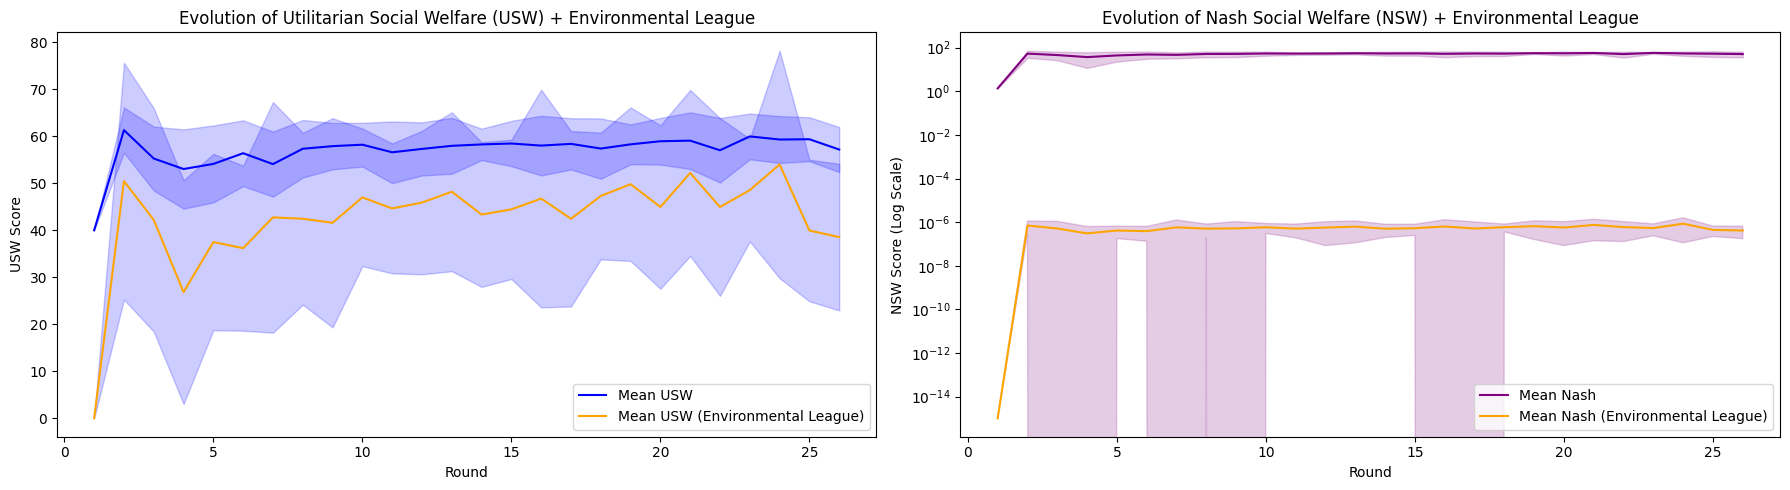

In [7]:
# Plot aggreated scores over rounds (Just like in the cell above), but now we can also plot a the scores of a single player

# GAME EVOLUTION + SINGLE PLAYER EVOLUTION

# Initialize lists to store scores per round across all games
num_rounds = 0
for file_ in answers_files:
    answers = json.load(open(file_))
    _num_rounds = len(answers['rounds'])
    num_rounds = max(num_rounds, _num_rounds)
usw_scores, esw_scores, nash_scores = [], [], []
player_usw_scores, player_esw_scores, player_nash_scores = [], [], []

player_role = ""  # Change this to the role of the player you want to analyze
player_name = "Environmental League"


if player_name == "":
    player_name = role_to_agents[player_role]

successfull_games = 0
# Loop through all answer files (each represents a game)
for file_ in answers_files:
    answers = json.load(open(file_))

    if len(answers['rounds']) != num_rounds:
        continue
    successfull_games += 1

    # Extract deals for this game
    game_usw, game_esw, game_nash = [], [], []
    game_player_usw, game_player_esw, game_player_nash = [], [], []

    for i, round_ in enumerate(answers['rounds']):
        name, answer = round_['agent'], round_['public_answer']
        deal_unformatted, threshold = evaluation.extract_deal(answer, ISSUES_NUM)
        deal = evaluation.format_deal(deal_unformatted, ISSUES_NUM)

        # Compute scores for this round
        usw = evaluation.compute_usw(deal, agents, ISSUES_NUM) / AGENTS_NUM
        esw = evaluation.compute_esw(deal, agents, ISSUES_NUM)
        nash = (evaluation.compute_nash(deal, agents, ISSUES_NUM))**(1/AGENTS_NUM)
        game_usw.append(usw)
        game_esw.append(esw)
        game_nash.append(nash)

        # Compute scores for the player
        player_usw = evaluation.utility_player_usw(deal, agents, player_name, ISSUES_NUM)
        player_esw = evaluation.utility_player_esw(deal, agents, player_name, ISSUES_NUM)
        player_nash = evaluation.utility_player_nash(deal, agents, player_name, ISSUES_NUM)
        game_player_usw.append(player_usw)
        game_player_esw.append(player_esw)
        game_player_nash.append(player_nash)

    # Store the game data
    usw_scores.append(game_usw)
    esw_scores.append(game_esw)
    nash_scores.append(game_nash)

    player_usw_scores.append(game_player_usw)
    player_esw_scores.append(game_player_esw)
    player_nash_scores.append(game_player_nash)


# Convert lists to NumPy arrays for statistical calculations
usw_scores = np.array(usw_scores)  # Shape: (20, num_rounds)
esw_scores = np.array(esw_scores)
nash_scores = np.array(nash_scores)
player_usw_scores = np.array(player_usw_scores)
player_esw_scores = np.array(player_esw_scores)
player_nash_scores = np.array(player_nash_scores)

# Compute mean and standard deviation
mean_usw, std_usw = np.mean(usw_scores, axis=0), np.std(usw_scores, axis=0) 
mean_esw, std_esw = np.mean(esw_scores, axis=0), np.std(esw_scores, axis=0)
mean_nash, std_nash = np.mean(nash_scores, axis=0), np.std(nash_scores, axis=0)
mean_player_usw, std_player_usw = np.mean(player_usw_scores, axis=0), np.std(player_usw_scores, axis=0)
mean_player_esw, std_player_esw = np.mean(player_esw_scores, axis=0), np.std(player_esw_scores, axis=0)
mean_player_nash, std_player_nash = np.mean(player_nash_scores, axis=0), np.std(player_nash_scores, axis=0)


# Plot the evolution of scores over rounds
rounds = np.arange(1, num_rounds + 1)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Plot USW Evolution
axes[0].plot(rounds, mean_usw, label="Mean USW", color="blue")
axes[0].plot(rounds, mean_player_usw, label=f"Mean USW ({player_name})", color="orange")
# axes[0].axhline(min_usw, color="red", linestyle="--", label=f"Min Acceptable USW = {min_usw}")
# axes[0].axhline(max_usw, color="green", linestyle="--", label=f"Max Acceptable USW = {max_usw}")
axes[0].fill_between(rounds, mean_usw - std_usw, mean_usw + std_usw, color="blue", alpha=0.2)
axes[0].fill_between(rounds, mean_player_usw - std_player_usw, mean_player_usw + std_player_usw, color="blue", alpha=0.2)
axes[0].set_title(f"Evolution of Utilitarian Social Welfare (USW) + {player_name}")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("USW Score")
axes[0].legend()

# Plot ESW Evolution-> Not insightful
# axes[1].plot(rounds, mean_esw, label="Mean ESW", color="green")
# axes[1].plot(rounds, mean_player_esw, label=f"Mean ESW ({player_name})", color="orange")
# axes[1].axhline(min_esw, color="red", linestyle="--", label=f"Min Acceptable ESW = {min_esw}")
# axes[1].axhline(max_esw, color="green", linestyle="--", label=f"Max Acceptable ESW = {max_esw}")
# axes[1].fill_between(rounds, mean_esw - std_esw, mean_esw + std_esw, color="green", alpha=0.2)
# axes[1].fill_between(rounds, mean_player_esw - std_player_esw, mean_player_esw + std_player_esw, color="green", alpha=0.2)
# axes[1].set_title(f"Evolution of Egalitarian Social Welfare (ESW) + {player_name}")
# axes[1].set_xlabel("Round")
# axes[1].set_ylabel("ESW Score")
# axes[1].legend()

# Plot Nash Evolution 
axes[1].plot(rounds, mean_nash, label="Mean Nash", color="purple")
axes[1].plot(rounds, mean_player_nash, label=f"Mean Nash ({player_name})", color="orange")
# axes[1].axhline(min_nash, color="red", linestyle="--", label=f"Min Acceptable Nash = {min_nash}")
# axes[1].axhline(max_nash, color="green", linestyle="--", label=f"Max Acceptable Nash = {max_nash}")
axes[1].fill_between(rounds, mean_nash - std_nash, mean_nash + std_nash, color="purple", alpha=0.2)
axes[1].fill_between(rounds, mean_player_nash - std_player_nash, mean_player_nash + std_player_nash, color="purple", alpha=0.2)
axes[1].set_title(f"Evolution of Nash Social Welfare (NSW) + {player_name}")
axes[1].set_xlabel("Round")
# Log scale for NSW
axes[1].set_yscale("log")
axes[1].set_ylabel("NSW Score (Log Scale)")
axes[1].legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()

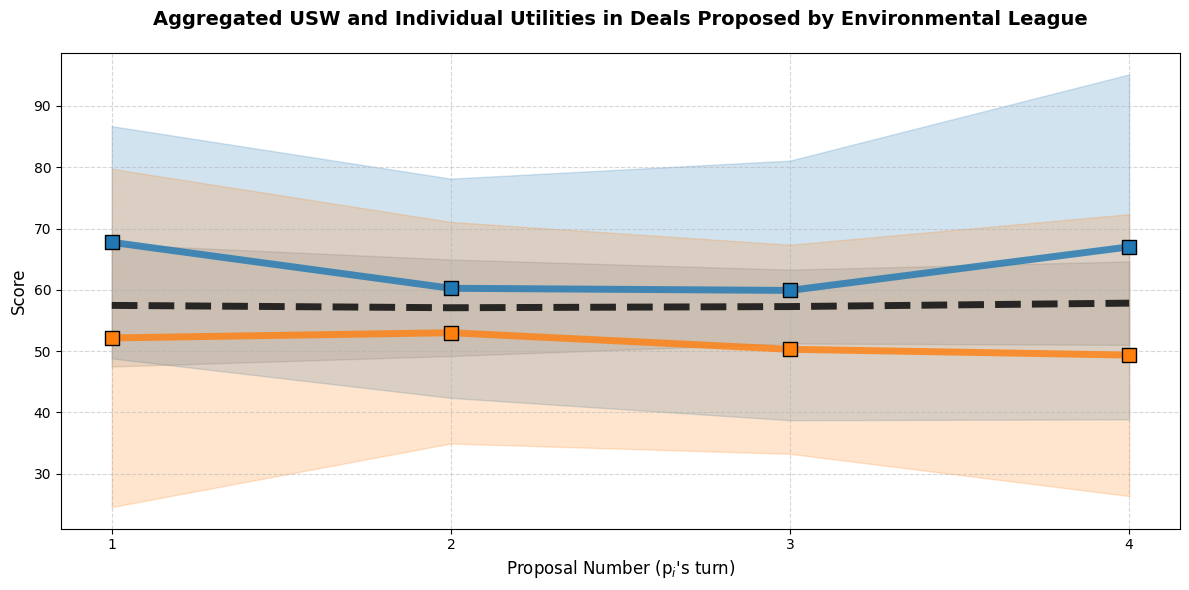

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import json

# Initialize lists to store scores per round across all games
num_rounds = None  # Determined dynamically based on the first player's proposals
#agent_names = ["Environmental League"]  # List of agent names to track utilities for (cooperative and greedy plots)
agent_names = ["Environmental League", "Local Labour Union"]  # List of agent names to track utilities for (adversarial plots)
first_player = agent_names[0]  # Focus on deals proposed by the first player

# Dictionary to store scores for each agent
agent_scores = {name: {'usw': [], 'player_usw': []} for name in agent_names}
aggregated_usw_scores = []  # To store aggregated USW scores across all agents

for file_ in answers_files:
    answers = json.load(open(file_))
    
    # Lists to store scores for this game (only first player's proposals)
    game_scores = {name: {'usw': [], 'player_usw': []} for name in agent_names}
    game_aggregated_usw = []  # To store aggregated USW for this game
    
    for round_ in answers['rounds']:
        name = round_['agent']
        if name != first_player:
            continue  # Skip rounds not proposed by the first player
        
        answer = round_['public_answer']
        deal_unformatted, threshold = evaluation.extract_deal(answer, ISSUES_NUM)
        deal = evaluation.format_deal(deal_unformatted, ISSUES_NUM)
        
        # Compute aggregated USW
        usw = evaluation.compute_usw(deal, agents, ISSUES_NUM) / AGENTS_NUM
        game_aggregated_usw.append(usw)
        
        # For each agent, compute their individual USW and store aggregated USW
        for agent_name in agent_names:
            player_usw = evaluation.utility_player_usw(deal, agents, agent_name, ISSUES_NUM)
            game_scores[agent_name]['player_usw'].append(player_usw)
            game_scores[agent_name]['usw'].append(usw)
    
    # Ensure all games have the same number of first player's proposals
    if num_rounds is None:
        num_rounds = len(game_aggregated_usw)
    else:
        assert len(game_aggregated_usw) == num_rounds, "Mismatch in first player's proposals between games"
    
    # Append game data
    aggregated_usw_scores.append(game_aggregated_usw)
    for name in agent_names:
        agent_scores[name]['usw'].append(game_scores[name]['usw'])
        agent_scores[name]['player_usw'].append(game_scores[name]['player_usw'])

# Convert to NumPy arrays
aggregated_usw_scores = np.array(aggregated_usw_scores)
for name in agent_names:
    agent_scores[name]['usw'] = np.array(agent_scores[name]['usw'])
    agent_scores[name]['player_usw'] = np.array(agent_scores[name]['player_usw'])

# Compute means and stds
mean_aggregated_usw = np.mean(aggregated_usw_scores, axis=0)
std_aggregated_usw = np.std(aggregated_usw_scores, axis=0)

agent_means_stds = {name: {} for name in agent_names}
for name in agent_names:
    agent_means_stds[name]['mean_usw'] = np.mean(agent_scores[name]['usw'], axis=0)
    agent_means_stds[name]['std_usw'] = np.std(agent_scores[name]['usw'], axis=0)
    agent_means_stds[name]['mean_player_usw'] = np.mean(agent_scores[name]['player_usw'], axis=0)
    agent_means_stds[name]['std_player_usw'] = np.std(agent_scores[name]['player_usw'], axis=0)

# Plotting
rounds = np.arange(1, num_rounds + 1)
plt.figure(figsize=(12, 6))

# Define a color palette for agents
colors = plt.cm.tab10.colors  # Use a predefined color map for distinct colors

# Plot aggregated USW
plt.plot(rounds, mean_aggregated_usw, label="Aggregated USW", color="black", linestyle="--", linewidth=5, alpha=0.8)
plt.fill_between(rounds, mean_aggregated_usw - std_aggregated_usw, mean_aggregated_usw + std_aggregated_usw, color="black", alpha=0.1)

# Plot individual agents' utilities
for idx, name in enumerate(agent_names):
    color = colors[idx % len(colors)]
    plt.plot(rounds, agent_means_stds[name]['mean_player_usw'], label=f"{name}'s Utility", color=color, linestyle="-", linewidth=5, alpha=0.8)
    plt.scatter(rounds, agent_means_stds[name]['mean_player_usw'], color=color, marker="s", s=100, edgecolor='black', zorder=5)
    plt.fill_between(rounds, 
                     agent_means_stds[name]['mean_player_usw'] - agent_means_stds[name]['std_player_usw'], 
                     agent_means_stds[name]['mean_player_usw'] + agent_means_stds[name]['std_player_usw'], 
                     color=color, alpha=0.2)

# Improve plot aesthetics
plt.title(f"Aggregated USW and Individual Utilities in Deals Proposed by {first_player}", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Proposal Number (p$_i$'s turn)", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rounds, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
# plt.legend(loc="lower right", fontsize=24)
plt.tight_layout()

plt.show()